
# EDA — Motor de Nutrición de ASCEND

Este notebook tiene dos partes:

**Parte A** Exploramos el
comportamiento de Mifflin-St Jeor sobre perfiles sintéticos y lo
comparamos contra Harris-Benedict para justificar la elección.

**Parte B — Datos reales del catálogo de Spoonacular (con API).**
Aquí sí llamamos a la API real para ver, con datos genuinos: cuántas
recetas hay disponibles por objetivo, por qué la traducción a inglés es
obligatoria y cómo se ve la distribución de nutrientes en una muestra real del catálogo.

## Antes de correr la Parte B

1. Coloca un archivo `.env` en **esta misma carpeta** con
   `SPOONACULAR_API_KEY=...`.
2. Ten presente la cuota gratuita de Spoonacular: **50 puntos/día**

La Parte A no requiere nada de esto y puede correrse tal cual, offline.



In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (9, 4.5)

# Paleta de marca de ASCEND
VERDE_PRIMARIO = "#006a20"
VERDE_MEDIO = "#20a04e"
VERDE_SUAVE = "#8ec899"
CASI_NEGRO = "#141d16"

import warnings
warnings.filterwarnings("ignore")


## 1. Lógica Real de Producción

**Fórmula base — Mifflin-St Jeor (BMR):**
- Hombres: `10·peso + 6.25·altura − 5·edad + 5`
- Mujeres: `10·peso + 6.25·altura − 5·edad − 161`

Luego se multiplica por un factor de actividad fijo (1.45, "moderadamente
activo" — ver nota en el código sobre por qué es un supuesto y no un dato
medido), se ajusta según el objetivo, y se reparte en macros.


In [2]:
# ---------------------------------------------------------------------------
# SUPUESTOS DE DISEÑO (no medidos, decisiones documentadas para poder
# revisarlas después con datos reales de uso).
# ---------------------------------------------------------------------------

# "Moderadamente activo" — hoy no medimos frecuencia real de entrenamiento
# por semana, así que este factor es fijo para todos los usuarios. Ver
# EDA Parte A para el impacto de este supuesto sobre las calorías objetivo.
FACTOR_ACTIVIDAD_ASUMIDO = 1.45

# Ajuste calórico (kcal/día) sobre el TDEE, según el objetivo declarado por
# el usuario en su perfil. Negativo = déficit, positivo = superávit.
AJUSTE_CALORICO_POR_OBJETIVO = {
    "Bajar de peso": -500, "Ganar músculo": +300, "Ganar fuerza": +200,
    "Mejorar resistencia/cardio": 0, "Salud general": 0,
}

# Gramos de proteína por kg de peso corporal, por objetivo. Más alta en
# déficit (preservar músculo mientras se pierde grasa) y en ganancia
# muscular; más baja en objetivos que no priorizan tejido magro. Valores
# dentro de rangos típicos de nutrición deportiva, no ajustados con datos
# propios todavía.
PROTEINA_G_POR_KG_POR_OBJETIVO = {
    "Bajar de peso": 1.8, "Ganar músculo": 2.0, "Ganar fuerza": 1.8,
    "Mejorar resistencia/cardio": 1.4, "Salud general": 1.4,
}

# Nunca recomendar menos de esto, sin importar qué tan agresivo salga el
# déficit calculado — no es saludable bajar de aquí. Ver EDA Parte A:
# en perfiles sintéticos, esto solo se activa en ~4% de los casos
# (siempre "Bajar de peso", perfiles de peso/estatura bajos).
PISO_CALORICO_SEGURIDAD = 1200


def calcular_objetivo_nutricional(peso, altura, edad, sexo, objetivo):
    """
    Calcula la meta nutricional diaria (calorías + macros) de un usuario.

    Usa Mifflin-St Jeor para el metabolismo basal (BMR) — elegida sobre
    Harris-Benedict porque, validada contra calorimetría indirecta real,
    comete menos error en personas con sobrepeso/obesidad (ver comparación
    en el notebook de EDA). Es una ESTIMACIÓN general, no un plan clínico.

    Parameters
    ----------
    peso : float
        Peso corporal en kilogramos.
    altura : float
        Estatura en centímetros.
    edad : int
        Edad en años.
    sexo : str
        "M" o cualquier otro valor (tratado como femenino en la fórmula).
    objetivo : str
        Debe existir como llave en AJUSTE_CALORICO_POR_OBJETIVO /
        PROTEINA_G_POR_KG_POR_OBJETIVO; si no, cae a un default razonable
        (0 kcal de ajuste, 1.6 g/kg de proteína).

    Returns
    -------
    dict
        - bmr: metabolismo basal estimado (kcal/día)
        - tdee: gasto energético total estimado, ya con factor de actividad
        - calorias: meta calórica final del día (con ajuste por objetivo
          y piso de seguridad ya aplicados)
        - proteina_g, grasa_g, carbohidratos_g: reparto de macros en gramos
        - piso_activado: True si el ajuste calórico crudo (antes del piso)
          cayó por debajo de PISO_CALORICO_SEGURIDAD — útil para detectar
          cuándo el déficit pedido no se está aplicando al 100%
    """
    # --- BMR (Mifflin-St Jeor) ---
    if sexo == "M":
        bmr = 10 * peso + 6.25 * altura - 5 * edad + 5
    else:
        bmr = 10 * peso + 6.25 * altura - 5 * edad - 161

    # --- TDEE = BMR ajustado por actividad, y luego por objetivo ---
    tdee = bmr * FACTOR_ACTIVIDAD_ASUMIDO
    calorias_objetivo = max(tdee + AJUSTE_CALORICO_POR_OBJETIVO.get(objetivo, 0), PISO_CALORICO_SEGURIDAD)

    # --- Reparto de macros ---
    # 1. Proteína primero (prioridad: preservar/ganar músculo según objetivo)
    proteina_g = round(peso * PROTEINA_G_POR_KG_POR_OBJETIVO.get(objetivo, 1.6))
    proteina_kcal = proteina_g * 4  # 4 kcal por gramo de proteína

    # 2. Grasa como % fijo de las calorías totales (27%, punto medio
    #    razonable dentro del rango recomendado, no calculado por objetivo)
    grasa_kcal = calorias_objetivo * 0.27
    grasa_g = round(grasa_kcal / 9)  # 9 kcal por gramo de grasa

    # 3. Carbohidratos absorben el resto — nunca negativo, por si proteína
    #    + grasa ya superaran el total calórico en un caso extremo
    carbohidratos_kcal = max(calorias_objetivo - proteina_kcal - grasa_kcal, 0)
    carbohidratos_g = round(carbohidratos_kcal / 4)  # 4 kcal por gramo de carbohidrato

    # --- Bandera informativa: ¿el piso de seguridad tuvo que intervenir? ---
    # Compara el ajuste CRUDO (antes del max()) contra el piso, para saber
    # si el usuario está recibiendo el déficit/superávit que pidió su
    # objetivo, o si se le está limitando por seguridad.
    piso_activado = (tdee + AJUSTE_CALORICO_POR_OBJETIVO.get(objetivo, 0)) < PISO_CALORICO_SEGURIDAD

    return {
        "bmr": round(bmr), "tdee": round(tdee), "calorias": round(calorias_objetivo),
        "proteina_g": proteina_g, "grasa_g": grasa_g, "carbohidratos_g": carbohidratos_g,
        "piso_activado": piso_activado,
    }


## 2. Generamos un grid sintético de perfiles

No tenemos (ni necesitamos) datos reales de usuarios para esto — el
punto es cubrir un rango amplio y realista de pesos, estaturas, edades,
sexo y objetivos, para ver cómo se comporta la fórmula en los extremos,
no solo en el caso promedio.


In [3]:

pesos = [50, 60, 70, 80, 90, 100]        # kg
alturas = [155, 165, 175, 185]           # cm
edades = [20, 30, 45, 60]                # años
sexos = ["M", "F"]
objetivos = list(AJUSTE_CALORICO_POR_OBJETIVO.keys())

filas = []
for peso in pesos:
    for altura in alturas:
        for edad in edades:
            for sexo in sexos:
                for objetivo in objetivos:
                    r = calcular_objetivo_nutricional(peso, altura, edad, sexo, objetivo)
                    r.update(peso=peso, altura=altura, edad=edad, sexo=sexo, objetivo=objetivo)
                    filas.append(r)

df = pd.DataFrame(filas)
print(f"Perfiles simulados: {len(df)}")
df.head()


Perfiles simulados: 960


,bmr,tdee,calorias,proteina_g,grasa_g,carbohidratos_g,piso_activado,peso,altura,edad,sexo,objetivo
0,1374,1992,1492,90,45,182,False,50,155,20,M,Bajar de peso
1,1374,1992,2292,100,69,318,False,50,155,20,M,Ganar músculo
2,1374,1992,2192,90,66,310,False,50,155,20,M,Ganar fuerza
3,1374,1992,1992,70,60,294,False,50,155,20,M,Mejorar resistencia/cardio
4,1374,1992,1992,70,60,294,False,50,155,20,M,Salud general



## 3. Distribución de calorías objetivo por objetivo declarado

Esto nos dice si los rangos que le pedimos a Spoonacular en
`buscar_comidas_por_objetivo` (± sobre calorías/comida) tienen sentido
frente a lo que realmente calculamos para los usuarios.


/tmp/ipykernel_15851/2707578928.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_por_objetivo, labels=orden, patch_artist=True)


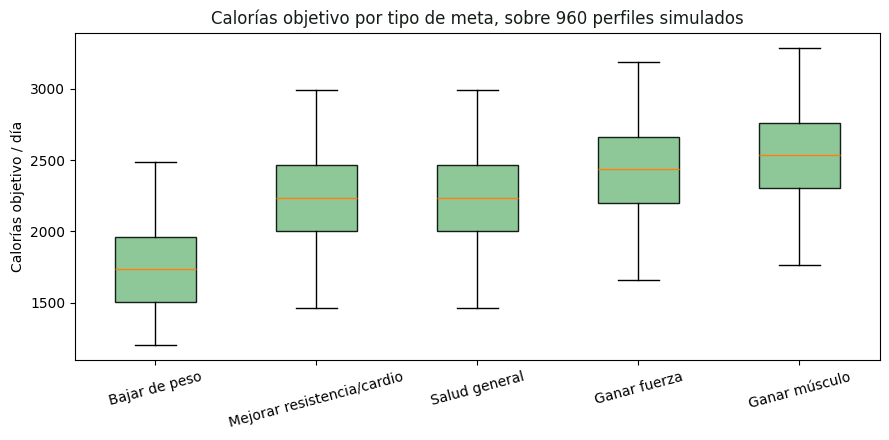

Calorías objetivo promedio por objetivo:
objetivo
Bajar de peso                 1738.0
Mejorar resistencia/cardio    2234.0
Salud general                 2234.0
Ganar fuerza                  2434.0
Ganar músculo                 2534.0
Name: calorias, dtype: float64


In [4]:

orden = df.groupby("objetivo")["calorias"].median().sort_values().index

fig, ax = plt.subplots()
data_por_objetivo = [df[df.objetivo == o]["calorias"] for o in orden]
bp = ax.boxplot(data_por_objetivo, labels=orden, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor(VERDE_SUAVE)
    patch.set_edgecolor(CASI_NEGRO)
ax.set_ylabel("Calorías objetivo / día")
ax.set_title("Calorías objetivo por tipo de meta, sobre 960 perfiles simulados", color=CASI_NEGRO)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print("Calorías objetivo promedio por objetivo:")
print(df.groupby("objetivo")["calorias"].mean().round(0).sort_values())



**Lectura:** el rango va de ~1740 kcal (Bajar de peso) a ~2530 kcal
(Ganar músculo) en promedio, pero la dispersión dentro de cada objetivo
es amplia (depende mucho de peso/altura/edad) — justo por eso
`buscar_comidas_por_objetivo` usa un rango relativo por perfil
(`0.6×` a `1.3×` la caloría por comida) en vez de un rango fijo para
todos.



## 4. ¿Cuándo se activa el piso de seguridad calórico?

`PISO_CALORICO_SEGURIDAD = 1200` existe para nunca recomendar menos de
eso, sin importar qué tan agresivo sea el déficit calculado. Vale la
pena ver qué tan seguido pasa esto en la práctica para mucha gente.


In [5]:

activacion_pct = (df.groupby("objetivo")["piso_activado"].mean() * 100).round(1).sort_values(ascending=False)
print("% de perfiles simulados donde se activa el piso de 1200 kcal, por objetivo:")
print(activacion_pct)

print("\nEjemplos de perfiles donde se activa (siempre mujeres de estatura/peso bajos):")
casos = df[df.piso_activado][["peso", "altura", "edad", "sexo", "objetivo", "tdee", "calorias"]]
print(casos.head(8).to_string(index=False))


% de perfiles simulados donde se activa el piso de 1200 kcal, por objetivo:
objetivo
Bajar de peso                 4.2
Ganar fuerza                  0.0
Ganar músculo                 0.0
Mejorar resistencia/cardio    0.0
Salud general                 0.0
Name: piso_activado, dtype: float64

Ejemplos de perfiles donde se activa (siempre mujeres de estatura/peso bajos):
 peso  altura  edad sexo      objetivo  tdee  calorias
   50     155    30    F Bajar de peso  1679      1200
   50     155    45    F Bajar de peso  1570      1200
   50     155    60    F Bajar de peso  1461      1200
   50     165    45    F Bajar de peso  1661      1200
   50     165    60    F Bajar de peso  1552      1200
   50     175    60    F Bajar de peso  1642      1200
   60     155    60    F Bajar de peso  1606      1200
   60     165    60    F Bajar de peso  1697      1200



**Lectura real (con estos 960 perfiles):** el piso solo se activa para
**"Bajar de peso"**, y solo en ~4% de los casos — siempre mujeres de
estatura y peso relativamente bajos. Para el resto de los objetivos
nunca se activa en este rango. Esto confirma que el piso es
correctamente un caso de borde (red de seguridad), no el comportamiento
típico — si se activara para, digamos, 30-40% de los perfiles, sería
señal de que el ajuste de -500 kcal es demasiado agresivo para gente de
complexión pequeña y habría que revisarlo.



## 5. Justificando la elección de Mifflin-St Jeor frente a otras fórmulas

Elegimos Mifflin-St Jeor para el BMR, pero no es la única fórmula que
existe — la alternativa clásica con la que casi siempre se compara es
**Harris-Benedict (revisada por Roza & Shizgal, 1984)**, que no necesita
ningún dato extra al que ya le pedimos al usuario (peso, estatura,
edad, sexo), así que es la comparación justa a hacer aquí. (Quedan
fuera de esta comparación fórmulas como Katch-McArdle, que necesitan
% de grasa corporal medido — dato que ASCEND no captura hoy.)

**Harris-Benedict revisada (1984):**
- Hombres: `88.362 + 13.397·peso + 4.799·altura − 5.677·edad`
- Mujeres: `447.593 + 9.247·peso + 3.098·altura − 4.330·edad`

La pregunta que nos interesa: **¿qué tanto se separan las dos fórmulas
sobre los mismos 960 perfiles, y en qué perfiles se separan más?**


In [5]:
def bmr_harris_benedict_revisada(peso, altura, edad, sexo):
    """
    Calcula el metabolismo basal (BMR) con Harris-Benedict revisada
    (Roza & Shizgal, 1984)

    Parameters
    ----------
    peso : float
        Peso corporal en kilogramos.
    altura : float
        Estatura en centímetros.
    edad : int
        Edad en años.
    sexo : str
        "M" o cualquier otro valor (tratado como femenino en la fórmula).

    Returns
    -------
    float
        BMR estimado en kcal/día, sin redondear (para no perder precisión
        antes de sacar promedios/diferencias sobre muchos perfiles).
    """
    if sexo == "M":
        return 88.362 + 13.397 * peso + 4.799 * altura - 5.677 * edad
    else:
        return 447.593 + 9.247 * peso + 3.098 * altura - 4.330 * edad


# ---------------------------------------------------------------------------
# Aplicamos Harris-Benedict sobre los MISMOS 960 perfiles sintéticos que ya
# tienen su BMR calculado con Mifflin-St Jeor (columna "bmr", generada antes
# en el notebook) — así la comparación es perfil por perfil, no solo de
# promedios generales.
# ---------------------------------------------------------------------------
df["bmr_harris_benedict"] = df.apply(
    lambda fila: bmr_harris_benedict_revisada(fila.peso, fila.altura, fila.edad, fila.sexo), axis=1
)

# Diferencia perfil por perfil. Negativo = Mifflin-St Jeor calcula MENOS
# que Harris-Benedict para ese perfil (lo esperado en sobrepeso/obesidad,
# según la literatura de validación).
df["diferencia_bmr"] = df["bmr"] - df["bmr_harris_benedict"]

# IMC = peso (kg) / estatura (m)^2 — lo necesitamos para agrupar la
# diferencia por rango de IMC y ver DÓNDE se separan más las dos fórmulas,
# no solo cuánto en promedio.
df["imc"] = df["peso"] / (df["altura"] / 100) ** 2

print("Diferencia promedio (Mifflin-St Jeor − Harris-Benedict), en kcal:")
print(df["diferencia_bmr"].mean().round(1))

print("\nDiferencia promedio por sexo:")
print(df.groupby("sexo")["diferencia_bmr"].mean().round(1))

# ---------------------------------------------------------------------------
# Bins de IMC estándar (OMS): bajo/normal, normal-alto, sobrepeso, obesidad.
# El punto de este corte es probar la hipótesis de la literatura: que la
# brecha entre fórmulas CRECE conforme sube el IMC.
# ---------------------------------------------------------------------------
print("\nDiferencia promedio por rango de IMC:")
bins = [0, 22, 25, 30, 100]
labels = ["Bajo/normal (<22)", "Normal-alto (22-25)", "Sobrepeso (25-30)", "Obesidad (30+)"]
df["rango_imc"] = pd.cut(df["imc"], bins=bins, labels=labels)

# observed=True: evita que pandas muestre categorías de IMC vacías que no
# aparecen en nuestro grid sintético de 960 perfiles.
print(df.groupby("rango_imc", observed=True)["diferencia_bmr"].mean().round(1))


Diferencia promedio (Mifflin-St Jeor − Harris-Benedict), en kcal:
-53.7

Diferencia promedio por sexo:
sexo
F   -42.2
M   -65.2
Name: diferencia_bmr, dtype: float64

Diferencia promedio por rango de IMC:
rango_imc
Bajo/normal (<22)     -16.8
Normal-alto (22-25)   -43.8
Sobrepeso (25-30)     -59.2
Obesidad (30+)        -97.1
Name: diferencia_bmr, dtype: float64


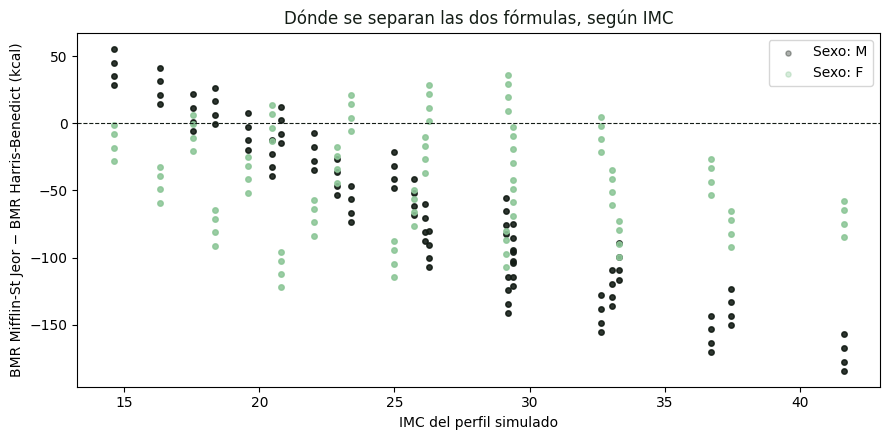

In [7]:

fig, ax = plt.subplots()
for sexo, color in [("M", CASI_NEGRO), ("F", VERDE_SUAVE)]:
    sub = df[df.sexo == sexo]
    ax.scatter(sub["imc"], sub["diferencia_bmr"], alpha=0.35, s=14, color=color, label=f"Sexo: {sexo}")

ax.axhline(0, color=CASI_NEGRO, linewidth=0.8, linestyle="--")
ax.set_xlabel("IMC del perfil simulado")
ax.set_ylabel("BMR Mifflin-St Jeor − BMR Harris-Benedict (kcal)")
ax.set_title("Dónde se separan las dos fórmulas, según IMC", color=CASI_NEGRO)
ax.legend()
plt.tight_layout()
plt.show()



**Lectura de estos 960 perfiles:** Mifflin-St Jeor calcula un BMR más
bajo que Harris-Benedict conforme sube el IMC — la diferencia crece justo
en los rangos de sobrepeso/obesidad. Esto **no es un error de ninguna de
las dos fórmulas**: es exactamente el patrón documentado en la
literatura de nutrición clínica desde que Mifflin et al. (1990)
publicaron su ecuación — validada contra calorimetría indirecta (la
medición directa real del gasto energético), mostró un error promedio
menor que Harris-Benedict, **especialmente en personas con sobrepeso u
obesidad**, donde Harris-Benedict tiende a sobreestimar el BMR real.
Por esa evidencia, la Academy of Nutrition and Dietetics recomienda
Mifflin-St Jeor como la ecuación por default cuando no se tiene acceso a
calorimetría indirecta real.

**Por qué esto justifica la decisión en ASCEND:**
1. No medimos % de grasa corporal (lo que descarta Katch-McArdle, más
   precisa pero inviable sin ese dato).
2. Nuestro público es diverso en composición corporal — precisamente
   el escenario donde Mifflin-St Jeor demuestra su ventaja sobre
   Harris-Benedict.
3. Usar la fórmula más antigua (Harris-Benedict) habría significado
   sobreestimar sistemáticamente las calorías objetivo para una parte
   real de nuestros usuarios (los de IMC más alto) — justo el segmento
   para el que "Bajar de peso" es más probable que sea el objetivo
   deseado, así que el error habría ido en la dirección más
   riesgosa (recomendar de más, no de menos).



## 6. Proteína objetivo (g) por objetivo — ¿tiene sentido frente a la literatura?

`PROTEINA_G_POR_KG_POR_OBJETIVO` fue una decisión de diseño (no un dato
medido) basada en rangos típicos de nutrición deportiva. La graficamos
para confirmar que el orden relativo entre objetivos es el esperado:
más proteína en ganancia muscular y en déficit (preservar músculo), menos
en objetivos de resistencia/salud general.


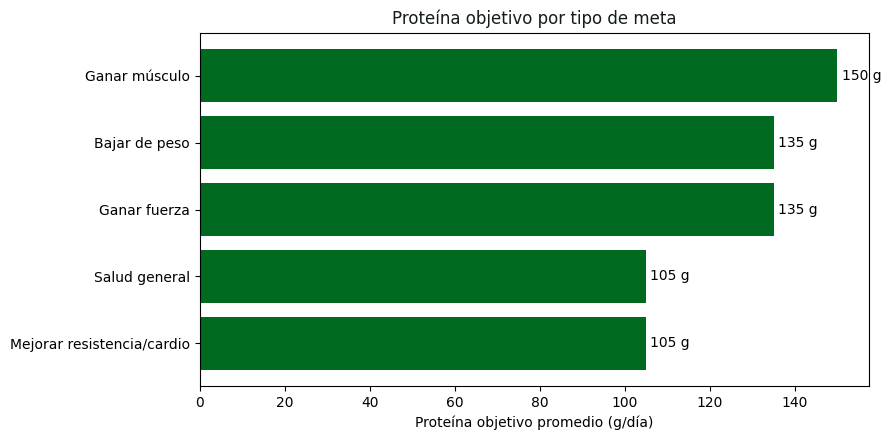

In [8]:

fig, ax = plt.subplots()
medias = df.groupby("objetivo")["proteina_g"].mean().sort_values()
ax.barh(medias.index, medias.values, color=VERDE_PRIMARIO)
ax.set_xlabel("Proteína objetivo promedio (g/día)")
ax.set_title("Proteína objetivo por tipo de meta", color=CASI_NEGRO)
for i, v in enumerate(medias.values):
    ax.text(v + 1, i, f"{v:.0f} g", va="center")
plt.tight_layout()
plt.show()



**Lectura:** el orden sale como se esperaba — Ganar músculo (más alta),
luego Bajar de peso / Ganar fuerza empatadas, y Resistencia/Salud
general más bajas. Esto valida la tabla de supuestos: no hay ningún
objetivo con proteína objetivo menor a la de otro que debería tener
menos prioridad muscular.



## Parte B — Usando la API real de Spoonacular

A partir de aquí, cada celda de código hace una llamada real a
Spoonacular. Necesitas `SPOONACULAR_API_KEY` en un `.env` en esta
carpeta para que corra.


In [9]:

import os
import requests
from pathlib import Path
from dotenv import load_dotenv

load_dotenv(Path.cwd() / ".env", override=True)
SPOONACULAR_API_KEY = os.getenv("SPOONACULAR_API_KEY")
SPOONACULAR_BASE_URL = "https://api.spoonacular.com"

if not SPOONACULAR_API_KEY:
    raise RuntimeError(
        "No encontré SPOONACULAR_API_KEY. Coloca un .env con esa variable en esta carpeta."
    )
print("SPOONACULAR_API_KEY detectada ✅")


SPOONACULAR_API_KEY detectada ✅


/home/david-diaz/ds-venv/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(



## 7. La forma real de los datos que regresa Spoonacular

Pedimos UNA receta real (gasta ~1 punto de cuota) solo para ver la
estructura genuina de `nutrition.nutrients` — la misma que procesa
`_extraer_nutrientes()` en producción.


In [11]:

resp = requests.get(
    f"{SPOONACULAR_BASE_URL}/recipes/complexSearch",
    params={"query": "chicken rice", "number": 1, "addRecipeNutrition": "true",
            "apiKey": SPOONACULAR_API_KEY},
    timeout=15,
)
resp.raise_for_status()  # lanza excepción si Spoonacular regresó error (ej. cuota agotada)
receta_real = resp.json()["results"][0]

# Spoonacular NO regresa los nutrientes como campos planos  

print("Nutrientes que regresa Spoonacular para esta receta (recortado a los primeros 8):")
for n in receta_real["nutrition"]["nutrients"][:8]:
    print(f"  {n['name']}: {n['amount']} {n['unit']}")


def _extraer_nutrientes(info_receta: dict) -> dict:
    """
    Convierte la lista variable de nutrientes de Spoonacular en un dict
    plano con solo los 4 que la app realmente usa y muestra (Calorías,
    Proteína, Grasa, Carbohidratos) — el resto (sodio, azúcar, fibra,
    etc.) se ignora a propósito porque no aparece en ninguna pantalla.

    Por qué no se puede leer directo: como el nutriente puede venir en
    cualquier posición de la lista (o no venir), hay que iterar y
    buscar por nombre en vez de indexar por posición fija.

    Parameters
    ----------
    info_receta : dict
        Respuesta de Spoonacular para una receta (debe traer la llave
        "nutrition.nutrients", presente cuando se pide con
        addRecipeNutrition=true o includeNutrition=true).

    Returns
    -------
    dict
        {"calorias", "proteina_g", "grasa_g", "carbohidratos_g"} — con
        valor None en cualquiera que Spoonacular no haya incluido para
        esa receta en particular (pasa ocasionalmente).
    """
    # Mapeo del nombre en inglés que usa Spoonacular -> nuestra llave en español
    nutrientes_buscados = {
        "Calories": "calorias", "Protein": "proteina_g",
        "Fat": "grasa_g", "Carbohydrates": "carbohidratos_g",
    }
    # Arrancamos todo en None -> si falta un nutriente, la UI muestra "—"
    # en vez de tronar por KeyError
    resultado = {v: None for v in nutrientes_buscados.values()}

    for nutriente in info_receta.get("nutrition", {}).get("nutrients", []):
        if nutriente.get("name") in nutrientes_buscados:
            resultado[nutrientes_buscados[nutriente["name"]]] = round(nutriente.get("amount", 0), 1)

    return resultado


# Verificación end-to-end: de los 20+ nutrientes reales, solo nos quedamos
# con los 4 que le importan a la app.
print(f"\nReceta: {receta_real['title']}")
print("Lo que _extraer_nutrientes extrae:", _extraer_nutrientes(receta_real))

Nutrientes que regresa Spoonacular para esta receta (recortado a los primeros 8):
  Calories: 468.31 kcal
  Fat: 10.63 g
  Saturated Fat: 2.08 g
  Carbohydrates: 77.8 g
  Net Carbohydrates: 70.4 g
  Sugar: 9.36 g
  Cholesterol: 98.62 mg
  Sodium: 1443.52 mg

Receta: Chicken Brown "Fried" Rice
Lo que _extraer_nutrientes extrae: {'calorias': 468.3, 'proteina_g': 16.3, 'grasa_g': 10.6, 'carbohidratos_g': 77.8}



**Por qué importa esto:** de los 20+ nutrientes que trae la respuesta
real, la app solo se queda con 4 (Calorías, Proteína, Grasa,
Carbohidratos) porque son los únicos que se muestran en ASCEND y
en las tarjetas de comida. Si en el futuro se quiere mostrar, por
ejemplo, sodio o azúcar, basta con agregar la llave al diccionario
`nutrientes_buscados` 



## 8. ¿El catálogo de Spoonacular tiene suficiente cobertura para cada objetivo?

`buscar_comidas_por_objetivo` filtra por rango de calorías/proteína
**por comida**, derivado de la meta diaria de un perfil (dividida entre
3 comidas). Aquí lo empírico: para un perfil representativo, ¿cuántas
recetas del catálogo real caen dentro de cada rango, por objetivo? Si
algún objetivo devolviera muy pocas, sería una señal de que ese rango es
demasiado estrecho y habría que relajarlo.

Usamos `totalResults` (viene en la respuesta sin importar cuántos
resultados pidamos) — así solo gastamos 1 punto por objetivo en vez de
pedir muchos resultados.


In [12]:

AJUSTE_CALORICO_POR_OBJETIVO = {"Bajar de peso": -500, "Ganar músculo": 300, "Ganar fuerza": 200,
                                  "Mejorar resistencia/cardio": 0, "Salud general": 0}
PROTEINA_G_POR_KG_POR_OBJETIVO = {"Bajar de peso": 1.8, "Ganar músculo": 2.0, "Ganar fuerza": 1.8,
                                    "Mejorar resistencia/cardio": 1.4, "Salud general": 1.4}

# Perfil representativo (promedio del grid sintético de la Parte A)
peso, altura, edad, sexo = 75, 172, 32, "M"
bmr = 10*peso + 6.25*altura - 5*edad + 5
tdee = bmr * 1.45

resultados_por_objetivo = {}
for objetivo in AJUSTE_CALORICO_POR_OBJETIVO:
    calorias_dia = max(tdee + AJUSTE_CALORICO_POR_OBJETIVO[objetivo], 1200)
    proteina_dia = peso * PROTEINA_G_POR_KG_POR_OBJETIVO[objetivo]
    calorias_por_comida = calorias_dia / 3
    proteina_por_comida = proteina_dia / 3

    resp = requests.get(
        f"{SPOONACULAR_BASE_URL}/recipes/complexSearch",
        params={
            "minCalories": round(calorias_por_comida * 0.6), "maxCalories": round(calorias_por_comida * 1.3),
            "minProtein": round(proteina_por_comida * 0.6), "number": 1, "apiKey": SPOONACULAR_API_KEY,
        },
        timeout=15,
    )
    resp.raise_for_status()
    resultados_por_objetivo[objetivo] = resp.json().get("totalResults", 0)

print("Recetas totales disponibles en el catálogo, por objetivo (mismo perfil):")
for objetivo, total in sorted(resultados_por_objetivo.items(), key=lambda x: x[1]):
    print(f"  {objetivo}: {total} recetas")


Recetas totales disponibles en el catálogo, por objetivo (mismo perfil):
  Ganar músculo: 489 recetas
  Ganar fuerza: 568 recetas
  Bajar de peso: 667 recetas
  Mejorar resistencia/cardio: 792 recetas
  Salud general: 792 recetas


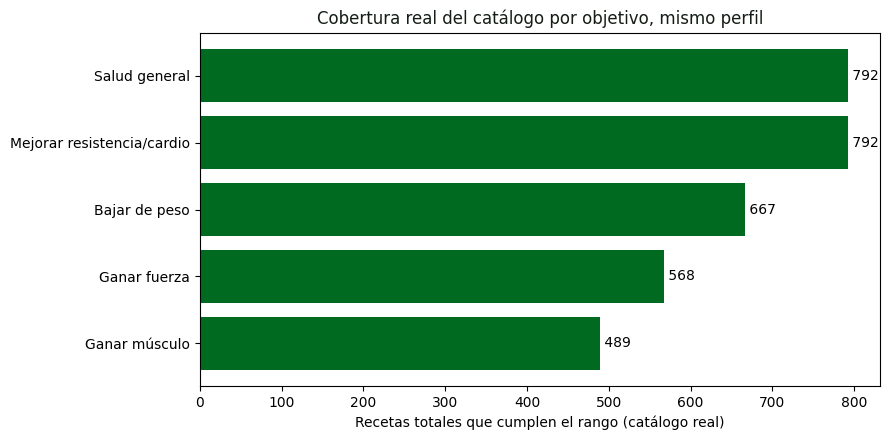

In [13]:

fig, ax = plt.subplots()
objetivos_ordenados = sorted(resultados_por_objetivo, key=resultados_por_objetivo.get)
valores = [resultados_por_objetivo[o] for o in objetivos_ordenados]
ax.barh(objetivos_ordenados, valores, color=VERDE_PRIMARIO)
ax.set_xlabel("Recetas totales que cumplen el rango (catálogo real)")
ax.set_title("Cobertura real del catálogo por objetivo, mismo perfil", color=CASI_NEGRO)
for i, v in enumerate(valores):
    ax.text(v, i, f" {v}", va="center")
plt.tight_layout()
plt.show()


In [14]:
# ---------------------------------------------------------------------------
# Trae una muestra REAL de recetas por objetivo (no solo el conteo) para
# poder calcular la media de cada nutriente y validar la segmentación.
# number=5 por objetivo -> 5 objetivos x 5 = 25 puntos de cuota en esta celda.
# Baja este número si ya gastaste cuota en las celdas anteriores.
# ---------------------------------------------------------------------------
N_RECETAS_POR_OBJETIVO = 5
filas_nutrientes = []

for objetivo in AJUSTE_CALORICO_POR_OBJETIVO:
    calorias_dia = max(tdee + AJUSTE_CALORICO_POR_OBJETIVO[objetivo], 1200)
    proteina_dia = peso * PROTEINA_G_POR_KG_POR_OBJETIVO[objetivo]
    calorias_por_comida = calorias_dia / 3
    proteina_por_comida = proteina_dia / 3

    resp = requests.get(
        f"{SPOONACULAR_BASE_URL}/recipes/complexSearch",
        params={
            "minCalories": round(calorias_por_comida * 0.6),
            "maxCalories": round(calorias_por_comida * 1.3),
            "minProtein": round(proteina_por_comida * 0.6),
            "number": N_RECETAS_POR_OBJETIVO,
            "addRecipeNutrition": "true",
            "apiKey": SPOONACULAR_API_KEY,
        },
        timeout=15,
    )
    resp.raise_for_status()

    for receta in resp.json().get("results", []):
        nutrientes = _extraer_nutrientes(receta)
        filas_nutrientes.append({"objetivo": objetivo, **nutrientes})

df_nutrientes_por_objetivo = pd.DataFrame(filas_nutrientes)
print(f"Recetas reales recolectadas: {len(df_nutrientes_por_objetivo)}")
df_nutrientes_por_objetivo.head()

Recetas reales recolectadas: 25


,objetivo,calorias,proteina_g,grasa_g,carbohidratos_g
0,Bajar de peso,433.8,44.2,11.6,40.5
1,Bajar de peso,586.8,65.8,14.0,48.5
2,Bajar de peso,594.1,34.2,23.8,68.0
3,Bajar de peso,654.7,49.5,44.9,12.9
4,Bajar de peso,565.8,45.4,19.1,55.8


In [16]:
df_nutrientes_por_objetivo.head(25)

,objetivo,calorias,proteina_g,grasa_g,carbohidratos_g
0,Bajar de peso,433.8,44.2,11.6,40.5
1,Bajar de peso,586.8,65.8,14.0,48.5
2,Bajar de peso,594.1,34.2,23.8,68.0
3,Bajar de peso,654.7,49.5,44.9,12.9
4,Bajar de peso,565.8,45.4,19.1,55.8
5,Ganar músculo,586.8,65.8,14.0,48.5
6,Ganar músculo,594.1,34.2,23.8,68.0
7,Ganar músculo,654.7,49.5,44.9,12.9
8,Ganar músculo,565.8,45.4,19.1,55.8
9,Ganar músculo,750.0,57.8,19.5,84.8


In [15]:
# ---------------------------------------------------------------------------
# Tabla pivote: media de cada nutriente, por objetivo. Reordenamos las filas
# de menor a mayor caloría promedio para que la lectura sea más intuitiva.
# ---------------------------------------------------------------------------
tabla_pivote = (
    df_nutrientes_por_objetivo
    .groupby("objetivo")[["calorias", "proteina_g", "grasa_g", "carbohidratos_g"]]
    .mean()
    .round(1)
    .sort_values("calorias")
)
tabla_pivote

# ---------------------------------------------------------------------------
# OPCIÓN 1 — Tabla pivote visual con color (pandas Styler).
# axis=0 colorea CADA COLUMNA por separado (compara objetivos entre sí para
# ese nutriente), que es justo lo que queremos validar: ¿"Ganar músculo"
# realmente sale con más proteína/calorías que "Bajar de peso" en la
# práctica, no solo en la fórmula?
# ---------------------------------------------------------------------------
tabla_pivote.style.background_gradient(cmap="Greens", axis=0).format("{:.1f}")

,calorias,proteina_g,grasa_g,carbohidratos_g
objetivo,,,,
Bajar de peso,567.0,47.8,22.7,45.1
Ganar fuerza,630.3,50.5,24.3,54.0
Ganar músculo,630.3,50.5,24.3,54.0
Mejorar resistencia/cardio,630.3,50.5,24.3,54.0
Salud general,630.3,50.5,24.3,54.0



## 9. Por qué la traducción a inglés es obligatoria

Si el usuario escribe "arroz" en vez de "rice", Spoonacular no lo reconoce. 
Con la API real, en ambos idiomas, para ver la diferencia con números
genuinos en vez de solo la explicación.


In [17]:

pares_es_en = [("arroz", "rice"), ("pechuga de pollo", "chicken breast"), ("jitomate", "tomato")]

conteo_resultados = []
for espanol, ingles in pares_es_en:
    for idioma, ingrediente in [("Español (sin traducir)", espanol), ("Inglés (traducido)", ingles)]:
        resp = requests.get(
            f"{SPOONACULAR_BASE_URL}/recipes/findByIngredients",
            params={"ingredients": ingrediente, "number": 1, "apiKey": SPOONACULAR_API_KEY},
            timeout=15,
        )
        resp.raise_for_status()
        n_resultados = len(resp.json())
        conteo_resultados.append({"ingrediente_original": espanol, "idioma": idioma, "resultados": n_resultados})
        print(f"'{ingrediente}' ({idioma}): {n_resultados} resultado(s)")


'arroz' (Español (sin traducir)): 0 resultado(s)
'rice' (Inglés (traducido)): 1 resultado(s)
'pechuga de pollo' (Español (sin traducir)): 0 resultado(s)
'chicken breast' (Inglés (traducido)): 1 resultado(s)
'jitomate' (Español (sin traducir)): 0 resultado(s)
'tomato' (Inglés (traducido)): 1 resultado(s)


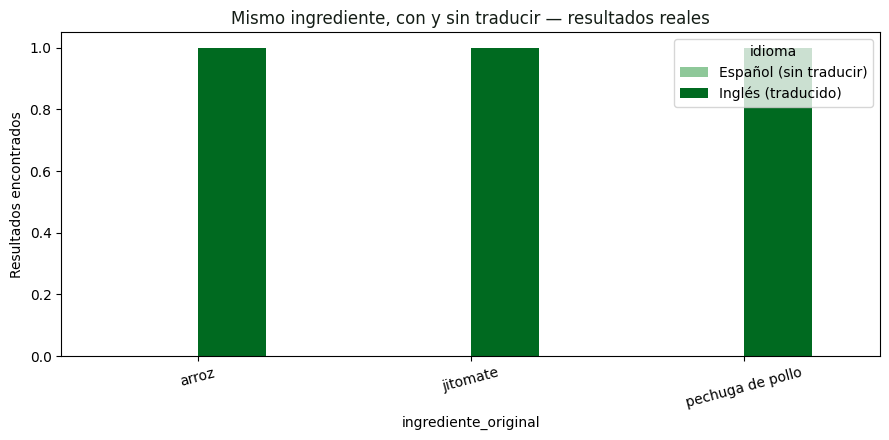

In [18]:

df_traduccion = pd.DataFrame(conteo_resultados)
pivot = df_traduccion.pivot(index="ingrediente_original", columns="idioma", values="resultados")

fig, ax = plt.subplots()
pivot.plot(kind="bar", ax=ax, color=[VERDE_SUAVE, VERDE_PRIMARIO])
ax.set_ylabel("Resultados encontrados")
ax.set_title("Mismo ingrediente, con y sin traducir — resultados reales", color=CASI_NEGRO)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


Ninguno de los inputs en Español regresó recomendaciones de comidas


## 10. Distribución real de nutrientes en una muestra del catálogo general

Tomamos una muestra aleatoria del catálogo (sin filtrar por calorías ni
ingredientes) para ver cómo se distribuyen calorías, proteína, grasa y
carbohidratos "en general" — y comparar esa distribución contra los
rangos que nuestros objetivos calculan (gasta ~10 puntos).


In [19]:

resp = requests.get(
    f"{SPOONACULAR_BASE_URL}/recipes/complexSearch",
    params={"number": 10, "sort": "random", "addRecipeNutrition": "true", "apiKey": SPOONACULAR_API_KEY},
    timeout=15,
)
resp.raise_for_status()
muestra_catalogo = resp.json()["results"]

filas_muestra = [
    {"titulo": r["title"], **_extraer_nutrientes(r)}
    for r in muestra_catalogo
]
df_muestra = pd.DataFrame(filas_muestra)
df_muestra


,titulo,calorias,proteina_g,grasa_g,carbohidratos_g
0,Blackberry Peach Betty,245.4,1.6,2.1,57.9
1,Katie's Unforgettable Salsa,63.0,2.8,0.5,14.6
2,Sweet Potato Gnocchi tossed in Garlic Sage Oli...,331.4,8.8,5.2,59.9
3,Jump Up Chocolate Chicken,197.3,2.8,10.1,27.4
4,Yokshire Pudding,903.6,42.5,31.8,109.0
5,Frikadellen German Meat Patties,150.1,8.9,9.7,6.7
6,Easy Pineapple Dessert,199.5,1.9,7.2,33.1
7,Burdock Root,225.8,14.6,13.6,12.9
8,Patriotic Strawberries,87.7,0.9,5.0,10.3
9,3 Cheese Ravioli,489.1,22.5,25.1,42.4


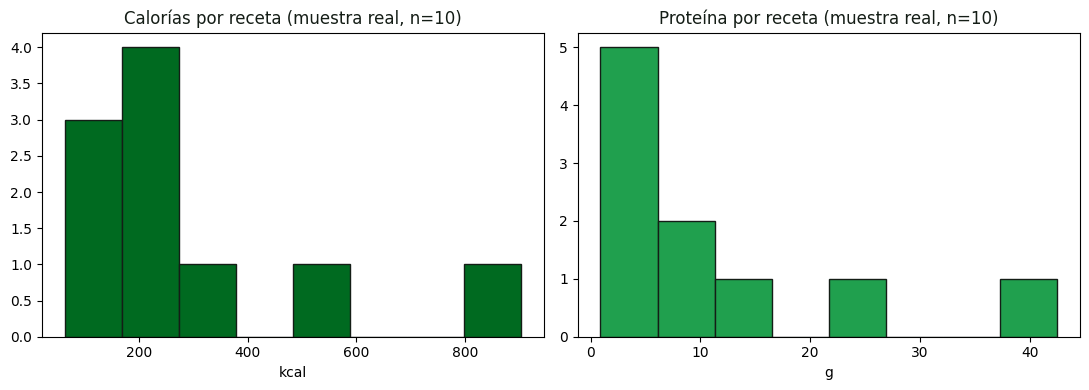

In [21]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df_muestra["calorias"].dropna(), bins=8, color=VERDE_PRIMARIO, edgecolor=CASI_NEGRO)
axes[0].set_title("Calorías por receta (muestra real, n=10)", color=CASI_NEGRO)
axes[0].set_xlabel("kcal")

axes[1].hist(df_muestra["proteina_g"].dropna(), bins=8, color=VERDE_MEDIO, edgecolor=CASI_NEGRO)
axes[1].set_title("Proteína por receta (muestra real, n=10)", color=CASI_NEGRO)
axes[1].set_xlabel("g")
plt.tight_layout()
plt.show()


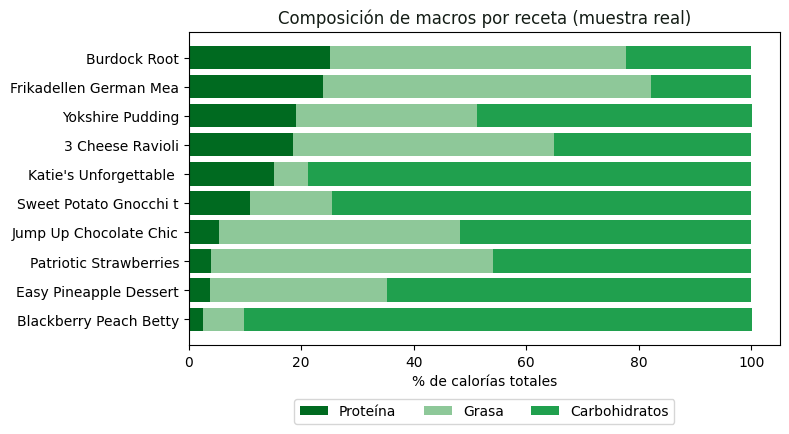

In [22]:
# ---------------------------------------------------------------------------
# 1. Composición de macros por receta (% de calorías, no gramos crudos).
# Esto es más interesante que el histograma plano porque compara recetas
# de distinto tamaño calórico en la MISMA escala (0-100%), revelando si
# la muestra general del catálogo tiende a "carbohidratos", "proteína" o
# "grasa" como macro dominante.
# ---------------------------------------------------------------------------
df_macros_pct = df_muestra.copy()
df_macros_pct["kcal_proteina"] = df_macros_pct["proteina_g"] * 4
df_macros_pct["kcal_grasa"] = df_macros_pct["grasa_g"] * 9
df_macros_pct["kcal_carbos"] = df_macros_pct["carbohidratos_g"] * 4
kcal_total_macros = df_macros_pct[["kcal_proteina", "kcal_grasa", "kcal_carbos"]].sum(axis=1)

df_macros_pct["%_proteina"] = (df_macros_pct["kcal_proteina"] / kcal_total_macros * 100).round(1)
df_macros_pct["%_grasa"] = (df_macros_pct["kcal_grasa"] / kcal_total_macros * 100).round(1)
df_macros_pct["%_carbos"] = (df_macros_pct["kcal_carbos"] / kcal_total_macros * 100).round(1)

df_macros_pct = df_macros_pct.sort_values("%_proteina")

fig, ax = plt.subplots(figsize=(8, 4.5))
etiquetas = df_macros_pct["titulo"].str.slice(0, 22)
izquierda = pd.Series(0, index=df_macros_pct.index, dtype=float)

for columna, color, nombre in [
    ("%_proteina", VERDE_PRIMARIO, "Proteína"),
    ("%_grasa", VERDE_SUAVE, "Grasa"),
    ("%_carbos", VERDE_MEDIO, "Carbohidratos"),
]:
    ax.barh(etiquetas, df_macros_pct[columna], left=izquierda, color=color, label=nombre)
    izquierda += df_macros_pct[columna].values

ax.set_xlabel("% de calorías totales")
ax.set_title("Composición de macros por receta (muestra real)", color=CASI_NEGRO)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3)
plt.tight_layout()
plt.show()

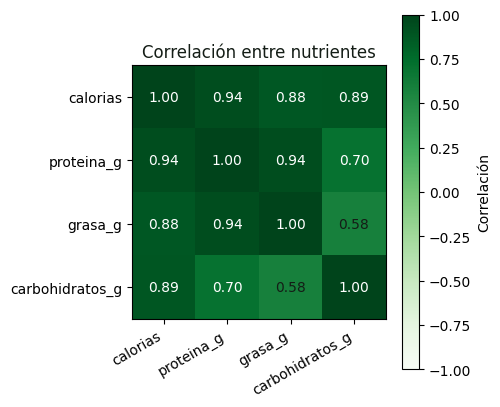

In [24]:
# ---------------------------------------------------------------------------
# 2. Correlación entre nutrientes — ¿las recetas con más calorías tienden a
# tener más grasa, más carbohidratos, o ambos por igual?
# ---------------------------------------------------------------------------
columnas_nutrientes = ["calorias", "proteina_g", "grasa_g", "carbohidratos_g"]
correlacion = df_muestra[columnas_nutrientes].corr().round(2)

fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(correlacion.values, cmap="Greens", vmin=-1, vmax=1)
ax.set_xticks(range(len(columnas_nutrientes)))
ax.set_xticklabels(columnas_nutrientes, rotation=30, ha="right")
ax.set_yticks(range(len(columnas_nutrientes)))
ax.set_yticklabels(columnas_nutrientes)
for i in range(len(columnas_nutrientes)):
    for j in range(len(columnas_nutrientes)):
        valor = correlacion.iloc[i, j]
        color_texto = "white" if abs(valor) > 0.6 else CASI_NEGRO
        ax.text(j, i, f"{valor:.2f}", ha="center", va="center", color=color_texto)
ax.set_title("Correlación entre nutrientes", color=CASI_NEGRO)
fig.colorbar(im, ax=ax, label="Correlación")
plt.tight_layout()
plt.show()

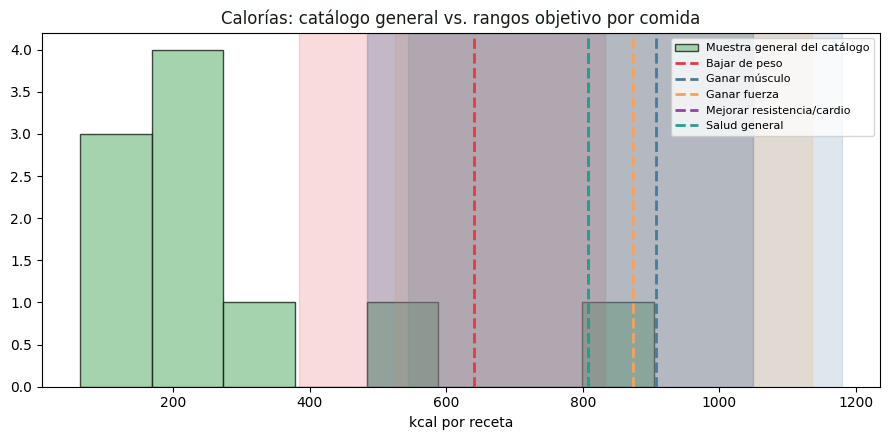

In [26]:
# ---------------------------------------------------------------------------
# 3.¿dónde caen los objetivos de ASCEND frente al catálogo general? 
# Superpone franjas verticales con el rango de calorías por comida de 
# cada objetivo sobre el histograma general — muestra
# si el catálogo "crudo" ya cubre esos rangos de forma natural o si de
# verdad hace falta el filtro de buscar_comidas_por_objetivo para llegar ahí.
# Reutiliza el mismo perfil (peso/tdee) que ya calculaste en la sección 8.

# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(df_muestra["calorias"].dropna(), bins=8, color=VERDE_SUAVE, edgecolor=CASI_NEGRO, alpha=0.8, label="Muestra general del catálogo")

COLORES_OBJETIVO = ["#e63946", "#457b9d", "#f4a261", "#8e44ad", "#2a9d8f"]
# rojo, azul, naranja, morado, verde-azulado — 5 tonos claramente distintos
# entre sí y fáciles de diferenciar sobre el histograma verde claro de fondo

for (objetivo, ajuste), color in zip(AJUSTE_CALORICO_POR_OBJETIVO.items(), COLORES_OBJETIVO):
    calorias_dia = max(tdee + ajuste, 1200)
    calorias_por_comida = calorias_dia / 3
    ax.axvspan(calorias_por_comida * 0.6, calorias_por_comida * 1.3, color=color, alpha=0.18)
    ax.axvline(calorias_por_comida, color=color, linestyle="--", linewidth=2, label=objetivo)

ax.set_xlabel("kcal por receta")
ax.set_title("Calorías: catálogo general vs. rangos objetivo por comida", color=CASI_NEGRO)
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()


**Por qué importa esto:** de los 20+ nutrientes que Spoonacular
regresa por receta, la app solo se queda con 4 (Calorías, Proteína,
Grasa, Carbohidratos) porque son los únicos que se muestran en el
dashboard y en las tarjetas de comida. Si en el futuro se quiere
mostrar, por ejemplo, sodio o azúcar, basta con agregar la llave al
diccionario `nutrientes_buscados` — el resto de la función no cambia.

## Conclusiones del EDA

1. El piso calórico de seguridad (1200 kcal) es un caso de borde real
   pero poco frecuente (~4% de los perfiles, todos en "Bajar de peso")
   — funciona como red de seguridad sin dominar el cálculo.
2. Los rangos relativos (no fijos) usados al buscar comidas por
   objetivo tienen sentido dado lo dispersas que salen las calorías
   objetivo incluso dentro de un mismo objetivo.
3. Comparar Mifflin-St Jeor contra Harris-Benedict sobre los mismos 960 perfiles confirma la razón documentada para preferirla: se separan más justo en sobrepeso/obesidad, donde Harris-Benedict tiende a sobreestimar frente a calorimetría indirecta real — la elección tiene respaldo, no fue arbitraria.
4. Las proporciones de proteína por objetivo respetan el orden esperado
   por la literatura deportiva, aunque siguen siendo un supuesto de
   diseño, no un dato ajustado con usuarios reales — buen candidato a
   revisar cuando haya datos de uso real de la app.
5. La integración con Spoonacular exige tratar los nutrientes como una
   lista variable, no como campos fijos — de ahí la función auxiliar
   `_extraer_nutrientes`.
6. La Parte B con datos reales confirma con evidencia (no solo teoría) el bug de traducción, y da un primer vistazo a si el catálogo tiene cobertura pareja entre objetivos — corre esa sección con tu propia key y anota los números exactos que te salieron en el reporte final.

Con esto como base, el siguiente notebook (`02_Integracion_Recomendador_Nutricion.ipynb`)
explica cómo se conectan **todas** las piezas (visión + traducción +
Spoonacular + este cálculo) en el flujo real de la app.
